<a id = "5" ></a>
# <span style="font-family:serif; font-size:28px;"> 1. Importing libraries</span>
<a id="loading"></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<a id = "5" ></a>
# <span style="font-family:serif; font-size:28px;"> 2. Loading data</span>
<a id="loading"></a>

In [2]:

data = pd.read_csv("electronics_products_pricing.csv")
print("Original Shape:", data.shape)
data.head()

Original Shape: (5436, 25)


,id,prices.availability,prices.condition,prices.currency,prices.dateSeen,prices.isSale,prices.merchant,prices.shipping,prices.sourceURLs,asins,...,imageURLs,keys,manufacturer,manufacturerNumber,name,primaryCategories,sourceURLs,upc,weight,price
0,AVphrugr1cnluZ0-FOeH,Yes,New,USD,"2017-05-10T20:00:00Z,2017-05-09T15:00:00Z",False,Bestbuy.com,NaN,http://www.bestbuy.com/site/products/7100293.p...,B00I9HD8PK,...,https://i5.walmartimages.com/asr/dd5f42c4-076c...,"819127010485,ecoxgearecostonebluetoothspeaker/...",Ecoxgear,GDI-EGST701,EcoXGear Ecostone Bluetooth Speaker,Electronics,http://www.walmart.com/ip/EcoXGear-Ecostone-Bl...,8.19E+11,3 pounds,92.99
1,AVrI6FDbv8e3D1O-lm4R,Yes,New,USD,"2017-10-10T02:00:00Z,2017-08-12T03:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/lenovo-100s-14ibr...,B06ZY63J8H,...,https://i5.walmartimages.com/asr/fcc50cce-a3c1...,"190793918948,lenovo100s14ibr14laptopintelceler...",NaN,100s-14ibr,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,Electronics,https://www.walmart.com/ip/Lenovo-100S-14IBR-1...,1.91E+11,4.3 pounds,229.99
2,AVpiLlubilAPnD_xBoTa,Yes,New,USD,"2017-10-10T19:00:00Z,2017-09-12T14:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/house-of-marley-s...,B00G3P9UMU,...,https://i5.walmartimages.com/asr/c124aa15-b9e3...,"0846885007037,houseofmarleysmilejamaicainearea...",House Of Marley,EM-JE041-MI,House of Marley Smile Jamaica In-Ear Earbuds,Electronics,https://www.walmart.com/ip/House-of-Marley-Smi...,8.47E+11,0.6 ounces,16.99
3,AVpgQP5vLJeJML43LQbd,Yes,New,USD,"2017-09-08T05:00:00Z,2017-09-18T13:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/products/6311012....,B00TTWZFFA,...,https://i5.walmartimages.com/asr/1be435f7-5f3a...,"sonyultraportablebluetoothspeaker/sosrsx11bk,s...",Sony,SRSX11/BLK,Sony Ultra-Portable Bluetooth Speaker,Electronics,https://www.walmart.com/ip/Sony-Ultra-Portable...,27242886599,1 pounds,69.99
4,AV1YDsmoGV-KLJ3adcbe,More on the Way,New,USD,2017-12-05T13:00:00Z,True,bhphotovideo.com,Free Expedited Shipping for most orders over $49,https://www.bhphotovideo.com/c/product/1105014...,B00MHPAF38,...,http://i.ebayimg.com/thumbs/images/g/TBUAAOSwd...,sonyalphaa5100digitalcamerakitwith1650mmlenswh...,NaN,ILCE5100L/W,Alpha a5100 Mirrorless Digital Camera with 16-...,Electronics,https://reviews.bestbuy.com/3545/8429343/revie...,27242883246,9.98 oz 4.09 oz,846.00


<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 3. Undertanding the data</span>
<a id = "Undertanding the data" ></a>

In [3]:
# Basic info about the dataset
dataset_info = data.info()
num_rows = data.shape[0]
num_cols = data.shape[1]

# Checking for missing values
missing_values = data.isnull().sum()

dataset_info, num_rows, num_cols, missing_values

<class 'pandas.DataFrame'>
RangeIndex: 5436 entries, 0 to 5435
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5436 non-null   str    
 1   prices.availability  5436 non-null   str    
 2   prices.condition     5436 non-null   str    
 3   prices.currency      5436 non-null   str    
 4   prices.dateSeen      5436 non-null   str    
 5   prices.isSale        5436 non-null   bool   
 6   prices.merchant      5436 non-null   str    
 7   prices.shipping      3199 non-null   str    
 8   prices.sourceURLs    5436 non-null   str    
 9   asins                5436 non-null   str    
 10  brand                5436 non-null   str    
 11  categories           5436 non-null   str    
 12  dateAdded            5436 non-null   str    
 13  dateUpdated          5436 non-null   str    
 14  ean                  1175 non-null   str    
 15  imageURLs            5436 non-null   str    
 16 

(None,
 5436,
 25,
 id                        0
 prices.availability       0
 prices.condition          0
 prices.currency           0
 prices.dateSeen           0
 prices.isSale             0
 prices.merchant           0
 prices.shipping        2237
 prices.sourceURLs         0
 asins                     0
 brand                     0
 categories                0
 dateAdded                 0
 dateUpdated               0
 ean                    4261
 imageURLs                 0
 keys                      0
 manufacturer           2959
 manufacturerNumber        0
 name                      0
 primaryCategories         0
 sourceURLs                0
 upc                       0
 weight                    0
 price                     0
 dtype: int64)

In [4]:
# Descriptive statistics for numerical features
print(data.describe())

# Descriptive statistics for categorical features
print(data.describe(include='object'))

             price
count  5436.000000
mean    492.941161
std     769.246463
min       1.000000
25%      79.950000
50%     194.410000
75%     486.952500
max    6999.990000
                          id prices.availability prices.condition  \
count                   5436                5436             5436   
unique                   819                  13               11   
top     AV1YFZVDvKc47QAVgp7V            In Stock              New   
freq                      41                2395             4645   

       prices.currency       prices.dateSeen prices.merchant  \
count             5436                  5436            5436   
unique               2                  3066             587   
top                USD  2018-05-26T15:00:00Z     Bestbuy.com   
freq              5435                   105            2109   

                                         prices.shipping  \
count                                               3199   
unique                                    

C:\Users\Samarth Gulati\AppData\Local\Temp\ipykernel_26684\1148265827.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))


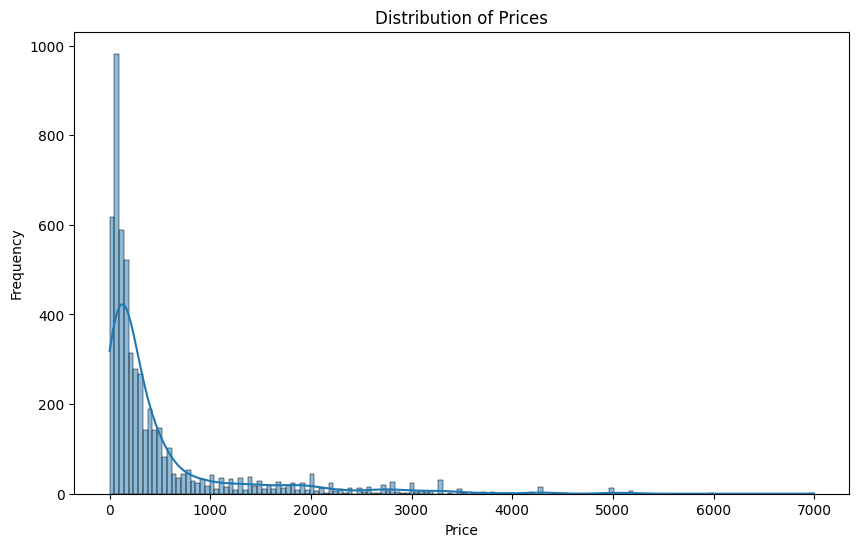

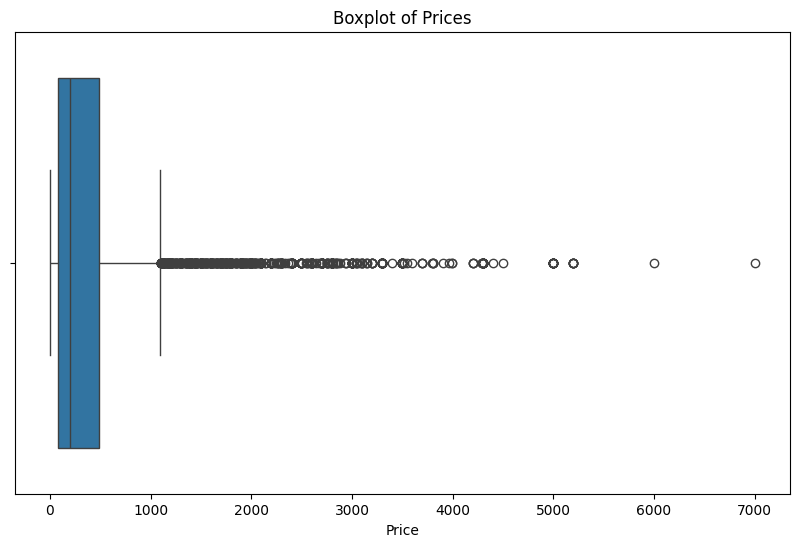

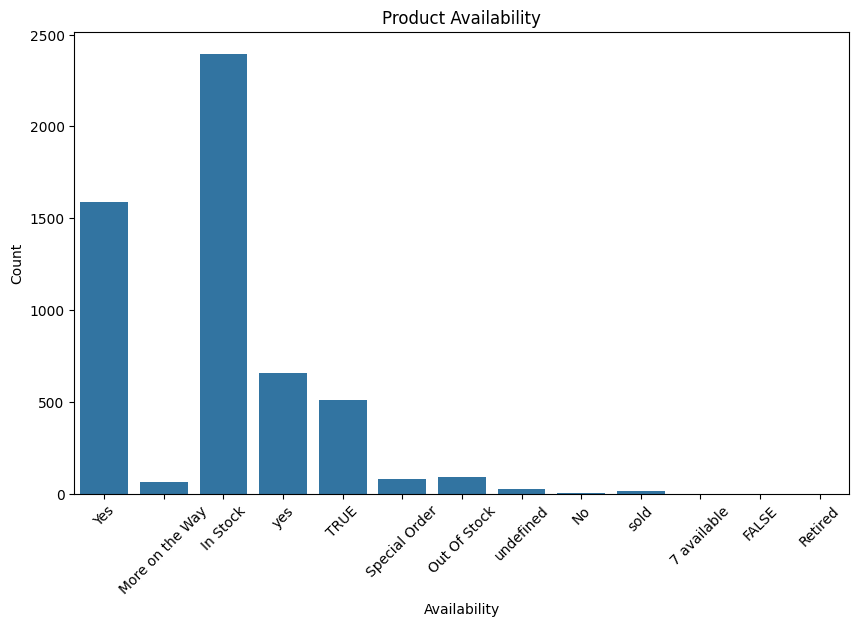

In [5]:
# Filtering numerical columns for correlation
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Histogram of the price column
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True)
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Boxplot of the price column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['price'])
plt.title('Boxplot of Prices')
plt.xlabel('Price')
plt.show()

# Count plot for the availability status
plt.figure(figsize=(10, 6))
sns.countplot(x='prices.availability', data=data)
plt.title('Product Availability')
plt.xlabel('Availability')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


<a id = "8" ></a>
# <span style="font-family:serif; font-size:28px;"> 4. Data Preprocessing </span>
<a id = "8" ></a>

In [6]:
#REMOVE IRRELEVANT COLUMNS

drop_columns = [
    'id','prices.sourceURLs','sourceURLs','imageURLs','keys',
    'ean','upc','prices.dateSeen','dateAdded','dateUpdated',
    'name','manufacturerNumber','asins'
]

data = data.drop(columns=drop_columns, errors='ignore')

In [7]:
#CLEAN TARGE
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])


In [8]:
#FEATURE ENGINEERING
if 'weight' in data.columns:
    data['weight_numeric'] = (
        data['weight']
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )
    data = data.drop(columns=['weight'])

print("Cleaned Shape:", data.shape)






Cleaned Shape: (5436, 12)


In [9]:
#DEFINE FEATURES & LOG TARGET
X = data.drop('price', axis=1)
y = np.log1p(data['price'])

#IDENTIFY COLUMN TYPES
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


C:\Users\Samarth Gulati\AppData\Local\Temp\ipykernel_26684\2334409061.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [10]:
#PREPROCESSING PIPELINE
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)




<a id = "8" ></a>
# <span style="font-family:serif; font-size:28px;"> 5. MODEL TRAINING </span>
<a id = "8" ></a>

In [11]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_test_actual = np.expm1(y_test)


In [12]:
#LINEAR REGRESSION
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = np.expm1(lr_pipeline.predict(X_test))

print("\nLINEAR REGRESSION RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_lr)))
print("R2:", r2_score(y_test_actual, y_pred_lr))




LINEAR REGRESSION RESULTS
MAE: 66.33794472379863
RMSE: 152.41263529860865
R2: 0.9564648938487725


In [13]:
#KNN REGRESSOR

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = np.expm1(knn_pipeline.predict(X_test))

print("\nKNN REGRESSOR RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_knn)))
print("R2:", r2_score(y_test_actual, y_pred_knn))



KNN REGRESSOR RESULTS
MAE: 152.9195424471953
RMSE: 334.7334949155847
R2: 0.7900112603262514


In [14]:
# DECISION TREE REGRESSOR


dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = np.expm1(dt_pipeline.predict(X_test))

print("\nDECISION TREE RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_dt)))
print("R2:", r2_score(y_test_actual, y_pred_dt))




DECISION TREE RESULTS
MAE: 147.53796843727156
RMSE: 291.9317906268297
R2: 0.8402795793521092


In [15]:
#RANDOM FOREST (TUNED)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [300, 500, 800],
    'regressor__max_depth': [20, 40, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

y_pred_rf = np.expm1(best_model.predict(X_test))

print("\nTUNED RANDOM FOREST RESULTS")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_rf)))
print("R2:", r2_score(y_test_actual, y_pred_rf))



TUNED RANDOM FOREST RESULTS
MAE: 98.05049469592961
RMSE: 236.782014120774
R2: 0.8949260439180163



Top 10 Important Features:
                                                Feature  Importance
0                                   num__weight_numeric    0.161509
1784                             cat__manufacturer_Sony    0.025077
763                                  cat__brand_Samsung    0.021459
692                                       cat__brand_LG    0.017536
63                    cat__prices.merchant_Beach Camera    0.015211
787                                     cat__brand_Sony    0.014939
1570  cat__categories_TVs & Electronics,4K Ultra HD ...    0.014342
1572  cat__categories_TVs & Electronics,4K Ultra HD ...    0.010934
1636                            cat__manufacturer_Apple    0.009696
601                                    cat__brand_Apple    0.009630


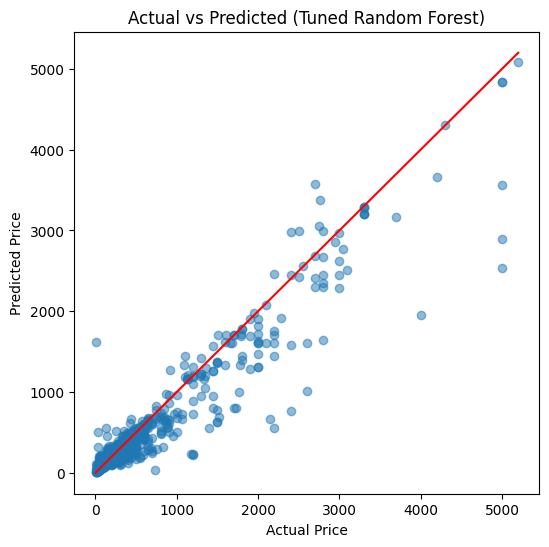

In [16]:
#FEATURE IMPORTANCE (RF)

feature_importances = best_model.named_steps['regressor'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

#ACTUAL VS PREDICTED PLOT

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Tuned Random Forest)")
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red')
plt.show()